# Regression Final Project - Predicting House Rent Prices in Adana/Turkey

## Assignment

**Objective:** The goal of this project is to develop a robust regression model using Deep Learning (TensorFlow/Keras) to predict apartment rental prices in your current city.

**Workflow:**

1- Data Collection: Navigate to real estate platforms such as Zingat, Hepsiemlak, or Emlakjet. Use web scraping techniques to extract active rent listings, including features like price, square meters (sqft), number of rooms, building age, and location.

2- Modeling: In addition to standard Machine Learning algorithms, you are required to implement a Deep Learning approach.

3- Technology Stack: Utilize TensorFlow and Keras to build a multi-layered neural network designed for regression.

4- Evaluation: Re-evaluate and predict house prices based on the features extracted, aiming for the lowest possible error in price estimation.

We will webscrape, therefore we would already have the rent prices. You may think, "If we already know the price, why are we predicting it?" Here is the fundamental reasoning behind this project and how it applies to the real world:

**1. "Smart Price Suggestion" for New Listings:** The main goal of your model is to determine the value of a house that is not yet on the market or has no price set.
- Scenario: A landlord wants to rent out their apartment but doesn't know the current market value. They enter "Adana, Çukurova, 3+1, 150m², 5th floor" into a system.
- The Model’s Role: Your Keras model looks at the patterns it learned from thousands of past listings and says: "Based on these features, the market value of this house should be approximately 22,500 TL."

**2. Detecting "Overpriced" Listings (Anomaly Detection):** Scraped data isn't always "perfect." Some listings are priced way above the market, and some are lower due to urgent needs.
- If your model predicts a house should cost 18,000 TL, but the actual price on the website is 28,000 TL, your model is telling you: "This house is overpriced; don't rent it!"

**3. Understanding Variable Impact (Feature Importance):** By building this model, you can answer scientific questions about the Adana market: "What increases the rent the most?"
- By looking at the "weights" in your Keras layers, you can see if adding an extra room increases the price more than, say, the building being brand new.

**The Project Workflow:**
1) Training Phase: You give the model 1,000 examples of house features AND their prices. The model solves the mathematical "riddle" (the function) connecting those features to the price.

2) Testing Phase: You give the model 100 houses where you have hidden the price. You ask the model: "Let’s see if you can guess these correctly."

3) Prediction: Now you have a reliable "Price Prediction Engine." If a friend asks, "What is my house worth?" you just plug their info into the model and get the answer.

**Keep in Mind:** When scraping, make sure to collect not just the price, but all the numerical (m², building age, floor) and categorical (neighborhood, heating type) information. The more "clues" (features) the Keras model has, the more accurate its predictions will be.

## Webscraping

I tried to scrape over Kaggle at first, however the websites understood that we were using bots. Therefore, I was unable to gather any data via Kaggle. I ran my codes after numerous updates over miniconda. I will upload webscraping file as a different file ('Webscraping') and attach to my assignment. When I need to restart my Kernel, I am having issues and need to scrape all over again. I will go on from this point in this notebook.

## Feature Engineering

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

import numpy as np

# 1. Load without a separator so every line is just one long string
df1 = pd.read_csv('adana_raw_v2.csv', sep='\t', names=['all_data'])

# 2. Split manually
# This will create as many columns as the widest row (18 columns)
df = df1['all_data'].str.split('|', expand=True)

# Apply strip to every object (string) column in the entire DataFrame
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
#In all of the columns we had extra null spaces in the beginning and end of every output, this one line cleaned all of the dataframe with one code.

print(df.shape)

(1463, 19)


In [2]:
pd.set_option('display.max_colwidth',None)

In [3]:
df.columns = ['ID', 'Price', 'Currency', 'Date', 'For_Rent', 'Rooms', 'Sqft', 'Building_Age', 'Floor', 'Headline', 'District', 'Extra1', 'Extra2', 'Extra3', 'Extra4', 'Extra5', 'Extra6', 'Extra7','Extra8']

In [4]:
df.head()

,ID,Price,Currency,Date,For_Rent,Rooms,Sqft,Building_Age,Floor,Headline,District,Extra1,Extra2,Extra3,Extra4,Extra5,Extra6,Extra7,Extra8
0,raw_text,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,35,20.000,TL,23/03/2026,Adana Seyhan Tellidere Mh Alparslan Türkeş Bulvarı 17 Yaşında Hasarsız 3+1 Kiralık Daire,Kiralık Daire,3 + 1,180 m²,16 Yaşında,5. Kat,Adana / Seyhan / Tellidere Mah.,Telefonu Göster,Mesaj,Whatsapp,Paylaş,,Adana City İnşaat Gayrimenkul,None,None
2,26,24.000,TL,16/03/2026,Kiralık Daire,3 + 1,135 m²,30 Yaşında,4. Kat,Adana Çukurova Toros Mahallesi 3+1 Kiralık Daire,Adana / Çukurova / Toros Mah.,Telefonu Göster,Mesaj,Whatsapp,Paylaş,None,None,None,None
3,23,19.500,TL,11/03/2026,Kiralık Daire,3 + 1,175 m²,28 Yaşında,Kot 2,Çukurova Mahfesıgmaz Turgut Özal İller Bankasına Yakın 3+1 Cazip Alternatifsiz,Adana / Çukurova / Mahfesığmaz Mah.,Telefonu Göster,Mesaj,Whatsapp,Paylaş,None,None,None,None
4,20,42.000,TL,28/02/2026,Kiralık Daire,2 + 1,110 m²,6 Yaşında,3. Kat,Atatürk Caddesinde Yeni Binada,Adana / Seyhan / Cemalpaşa Mah.,Telefonu Göster,Mesaj,Whatsapp,Paylaş,None,None,None,None


In [5]:
print(df.Extra1.value_counts())
print(df.Extra2.value_counts())
print(df.Extra3.value_counts())
print(df.Extra4.value_counts())
print(df.Extra5.value_counts())
print(df.Extra6.value_counts())
print(df.Extra7.value_counts())
print(df.Extra8.value_counts())

Extra1
Telefonu Göster                        1381
Mesaj                                    74
Adana / Çukurova / Toros Mah.             2
Adana / Sarıçam / Osmangazi Mah.          1
Geniş 3+1                                 1
Adana / Sarıçam / Gültepe Mah.            1
                                          1
Adana / Çukurova / Huzurevleri Mah.       1
Name: count, dtype: int64
Extra2
Mesaj                               1381
Whatsapp                              74
Telefonu Göster                        5
Net185 M2 Daıre                        1
Adana / Sarıçam / Osmangazi Mah.       1
Name: count, dtype: int64
Extra3
Whatsapp                             1381
Paylaş                                 74
Mesaj                                   5
Adana / Seyhan / Namık Kemal Mah.       1
Telefonu Göster                         1
Name: count, dtype: int64
Extra4
Paylaş             1381
                     33
Whatsapp              5
Telefonu Göster       1
Mesaj                 1
Name: c

In [6]:
df=df.drop(['Extra1','Extra2','Extra3','Extra4','Extra5','Extra6','Extra7','Extra8'],axis=1)

In [7]:
df = df.drop([0, 1]).reset_index(drop=True)
#I am deleting the first 2 rows since one of them has no meaningful data in, and other one has mixed up data that affecting all of the formulas to fix it along the way. Since I have numerous data, 1 line of data will not affect me.

In [8]:
df.head()

,ID,Price,Currency,Date,For_Rent,Rooms,Sqft,Building_Age,Floor,Headline,District
0,26,24.000,TL,16/03/2026,Kiralık Daire,3 + 1,135 m²,30 Yaşında,4. Kat,Adana Çukurova Toros Mahallesi 3+1 Kiralık Daire,Adana / Çukurova / Toros Mah.
1,23,19.500,TL,11/03/2026,Kiralık Daire,3 + 1,175 m²,28 Yaşında,Kot 2,Çukurova Mahfesıgmaz Turgut Özal İller Bankasına Yakın 3+1 Cazip Alternatifsiz,Adana / Çukurova / Mahfesığmaz Mah.
2,20,42.000,TL,28/02/2026,Kiralık Daire,2 + 1,110 m²,6 Yaşında,3. Kat,Atatürk Caddesinde Yeni Binada,Adana / Seyhan / Cemalpaşa Mah.
3,14,18.500,TL,17/03/2026,Kiralık Daire,1 + 1,55 m²,8 Yaşında,5. Kat,Toros Mahallesi Mavi Bulvarda 1+1 Kiralık Daire,Adana / Çukurova / Toros Mah.
4,12,25.000,TL,04/03/2026,Kiralık Daire,1 + 1,45 m²,Sıfır Bina,14. Kat,Barajyolunda Sıfır Kiralık Daire,Adana / Seyhan / Yenibaraj Mah.


In [9]:
df.isnull().sum()

,0
ID,0
Price,0
Currency,0
Date,0
For_Rent,0
Rooms,0
Sqft,0
Building_Age,0
Floor,0
Headline,0


In [10]:
print(df.District.value_counts())
print(df.District.unique())

District
Adana / Sarıçam / Gültepe Mah.           137
Adana / Sarıçam / Çarkıpare Mah.          87
Telefonu Göster                           74
Adana / Seyhan / Gürselpaşa Mah.          70
Adana / Çukurova / Huzurevleri Mah.       67
                                        ... 
Adana / Sarıçam / Kargakekeç Mah.          1
Adana / Yüreğir / Levent Mah.              1
Adana / Sarıçam / Hürriyet Mah.            1
Adana / Ceyhan / Belediye Evleri Mah.      1
Adana / Seyhan / Gökçeler Mah.             1
Name: count, Length: 117, dtype: int64
['Adana / Çukurova / Toros Mah.' 'Adana / Çukurova / Mahfesığmaz Mah.'
 'Adana / Seyhan / Cemalpaşa Mah.' 'Adana / Seyhan / Yenibaraj Mah.'
 'Adana / Sarıçam / İstiklal Mah.' 'Adana / Çukurova / Beyazevler Mah.'
 'Telefonu Göster' 'Adana / Kozan / Türkeli Mah.'
 'Adana / Sarıçam / Çarkıpare Mah.'
 'Adana / Sarıçam / Elif Su Uludağ Mah.' 'Adana / Seyhan / Pınar Mah.'
 'Adana / Çukurova / Yurt Mah.' 'Adana / Sarıçam / Gültepe Mah.'
 'Adana / Seyhan / Aydı

In [11]:
# 1. Clean whitespace and ensure string type
df['District'] = df['District'].astype(str).str.strip()

# 2. Keep only rows starting with 'Adana' (this automatically deletes 'Telefonu Göster' and invalid rows)
df = df[df['District'].str.startswith('Adana', na=False)]

In [12]:
df.District.isnull().sum()

np.int64(0)

In [13]:
print(df.Headline.value_counts())
print(df.Headline.unique())

Headline
Özal Aksa Gaz Civarı Nova Milanoda Kiralık 4+1 Lüx Daire            4
Kozan Divan Emlak'tan Yeni Toki'lerde Kiralık 3+1                   4
Tuncer'den Hasarsız Aylık Kiralık Daire                             3
Çukurova 100.Yılda Site İçi Güvenlikli Havuzlu 3+1 Kiralık Daire    2
Barajyolu Boğalar Mağazası Civarında Eşyalı Kiralık Daire           2
                                                                   ..
Ulucan'dan Huzurevlerin'de Sosyal Donatılı Kiralık                  1
Sarıçam Gültepede Eşyalı Kiralık 1+1 Daire                          1
Adana Koop Evleri'nde Geniş Metrekareli Kiralık Daire               1
Gültepede Bulvar Üzeri Sıfır Full Eşyalı Kiralık Daire              1
Gültepe'de 1+1 Klimalı 3'Lü Ankastreli Ve Şofbenli Kiralık Daire    1
Name: count, Length: 1345, dtype: int64
['Adana Çukurova Toros Mahallesi 3+1 Kiralık Daire'
 'Çukurova Mahfesıgmaz Turgut Özal İller Bankasına Yakın 3+1 Cazip Alternatifsiz'
 'Atatürk Caddesinde Yeni Binada' ...
 'Göl Man

In [14]:
df=df.drop(['Headline'],axis=1)

In [15]:
df.columns

Index(['ID', 'Price', 'Currency', 'Date', 'For_Rent', 'Rooms', 'Sqft',
       'Building_Age', 'Floor', 'District'],
      dtype='object')

In [16]:
print(df.Floor.unique())
print(df.Floor.value_counts())

['4. Kat' 'Kot 2' '3. Kat' '5. Kat' '14. Kat' '2. Kat' '11. Kat' 'Zemin'
 '1. Kat' '7. Kat' '6. Kat' '10. Kat' 'Bahçe Katı' '8. Kat' '12. Kat'
 '9. Kat' 'Yüksek Giriş' '13. Kat' 'Ara Kat' '16. Kat' 'En Üst Kat'
 '15. Kat' 'Giriş Katı' 'Kot 1' '20. Kat' 'Kot 3' '17. Kat' '21 ve üzeri'
 'Teras Katı' 'Bodrum' '18. Kat' '19. Kat' 'Yarı Bodrum']
Floor
1. Kat          155
2. Kat          154
3. Kat          142
4. Kat          131
7. Kat           91
6. Kat           88
5. Kat           85
8. Kat           81
Bahçe Katı       61
9. Kat           58
11. Kat          55
10. Kat          47
Yüksek Giriş     45
Zemin            33
12. Kat          31
13. Kat          27
Ara Kat          23
Giriş Katı       16
14. Kat          13
En Üst Kat        7
16. Kat           7
15. Kat           7
Kot 1             6
Kot 2             4
Teras Katı        3
17. Kat           2
Kot 3             2
20. Kat           1
21 ve üzeri       1
Bodrum            1
18. Kat           1
19. Kat           1
Yarı Bodrum

In [17]:
# 1. Map special names to numeric strings
mapping = {'Zemin': '0', 'Giriş Katı': '0', 'Bodrum': '-1', 'Kot 1': '-1', 'Kot 2': '-2'}
df['Floor'] = df['Floor'].replace(mapping)

# 2. Extract digits (the '0' at the end ensures we get a Series, not a DataFrame)
df['Floor'] = df['Floor'].str.extract('([-+]?\d+)')[0]

# 3. Convert to numeric, fill NaNs with 0, and turn into Integer (removes the '.')
df['Floor'] = pd.to_numeric(df['Floor'], errors='coerce').fillna(0).astype(int)

In [18]:
df.Floor.info()

<class 'pandas.core.series.Series'>
Index: 1380 entries, 0 to 1460
Series name: Floor
Non-Null Count  Dtype
--------------  -----
1380 non-null   int64
dtypes: int64(1)
memory usage: 21.6 KB


In [19]:
df.Floor.unique()

array([ 4, -2,  3,  5, 14,  2, 11,  0,  1,  7,  6, 10,  8, 12,  9, 13, 16,
       15, -1, 20, 17, 21, 18, 19])

In [20]:
print(df.Building_Age.value_counts())
print(df.Building_Age.unique())

Building_Age
Sıfır Bina    182
6 Yaşında     145
5 Yaşında     122
16 Yaşında     96
1 Yaşında      94
11 Yaşında     78
4 Yaşında      77
21 Yaşında     63
2 Yaşında      59
3 Yaşında      58
20 Yaşında     49
15 Yaşında     41
26 Yaşında     37
25 Yaşında     36
10 Yaşında     36
7 Yaşında      32
30 Yaşında     31
8 Yaşında      24
9 Yaşında      19
31 Yaşında     13
18 Yaşında     12
12 Yaşında     12
40 Yaşında      8
28 Yaşında      7
22 Yaşında      6
35 Yaşında      6
13 Yaşında      6
14 Yaşında      5
23 Yaşında      5
29 Yaşında      4
38 Yaşında      4
19 Yaşında      4
45 Yaşında      2
27 Yaşında      2
24 Yaşında      2
39 Yaşında      1
32 Yaşında      1
17 Yaşında      1
Name: count, dtype: int64
['30 Yaşında' '28 Yaşında' '6 Yaşında' '8 Yaşında' 'Sıfır Bina'
 '3 Yaşında' '22 Yaşında' '16 Yaşında' '9 Yaşında' '1 Yaşında'
 '21 Yaşında' '4 Yaşında' '10 Yaşında' '5 Yaşında' '7 Yaşında'
 '20 Yaşında' '14 Yaşında' '12 Yaşında' '2 Yaşında' '26 Yaşında'
 '45 Yaşında' '15 Yaşı

In [21]:
#We'll rename Sıfır Bina as 0 yrs old; get rid of 'Yaşında'; make it numeric.

# 1. Replace 'Sıfır Bina' with 0 and extract only the numbers (deletes 'Yaşında')
df['Building_Age'] = df['Building_Age'].str.replace('Sıfır Bina', '0', case=False).str.extract('(\d+)')[0]

# 2. Convert to numeric, fill any missing values with 0, and make it an Integer
df['Building_Age'] = pd.to_numeric(df['Building_Age'], errors='coerce').fillna(0).astype(int)


In [22]:
df.Building_Age.unique()

array([30, 28,  6,  8,  0,  3, 22, 16,  9,  1, 21,  4, 10,  5,  7, 20, 14,
       12,  2, 26, 45, 15, 35, 18, 23, 25, 39, 11, 40, 27, 19, 38, 13, 29,
       31, 32, 24, 17])

In [23]:
print(df.Sqft.value_counts())
print(df.Sqft.unique())


Sqft
60 m²     103
50 m²      81
55 m²      74
100 m²     69
150 m²     67
         ... 
82 m²       1
550 m²      1
43 m²       1
27 m²       1
26 m²       1
Name: count, Length: 89, dtype: int64
['135 m²' '175 m²' '110 m²' '55 m²' '45 m²' '121 m²' '330 m²' '220 m²'
 '85 m²' '140 m²' '150 m²' '65 m²' '145 m²' '100 m²' '165 m²' '169 m²'
 '385 m²' '50 m²' '90 m²' '210 m²' '170 m²' '250 m²' '60 m²' '120 m²'
 '155 m²' '130 m²' '180 m²' '200 m²' '70 m²' '105 m²' '75 m²' '40 m²'
 '160 m²' '125 m²' '190 m²' '300 m²' '240 m²' '265 m²' '30 m²' '80 m²'
 '92 m²' '35 m²' '350 m²' '159 m²' '147 m²' '72 m²' '136 m²' '95 m²'
 '115 m²' '215 m²' '185 m²' '164 m²' '260 m²' '230 m²' '500 m²' '157 m²'
 '39 m²' '44 m²' '48 m²' '225 m²' '290 m²' '400 m²' '25 m²' '61 m²'
 '195 m²' '270 m²' '280 m²' '38 m²' '58 m²' '205 m²' '98 m²' '68 m²'
 '154 m²' '310 m²' '168 m²' '106 m²' '107 m²' '340 m²' '37 m²' '57 m²'
 '178 m²' '74 m²' '52 m²' '158 m²' '82 m²' '550 m²' '43 m²' '27 m²'
 '26 m²']


In [24]:
# 1. Strip whitespace
df['Sqft'] = df['Sqft'].astype(str).str.strip()

# 2. Masking: If the string contains 'Yaşında' or 'Bina', turn it into NaN
# We use case=False to be safe
mask = df['Sqft'].str.contains('Yaşında|Bina', case=False, na=False)
df.loc[mask, 'Sqft'] = np.nan

# 3. Extract only the digits (to remove 'm²') and convert to float
df['Sqft'] = df['Sqft'].str.extract('(\d+)')[0]
df['Sqft'] = pd.to_numeric(df['Sqft'], errors='coerce')

# 4. (Optional) Remove rows where Size is now NaN to keep the data clean
df = df.dropna(subset=['Sqft'])

print(df['Sqft'].unique())

[135 175 110  55  45 121 330 220  85 140 150  65 145 100 165 169 385  50
  90 210 170 250  60 120 155 130 180 200  70 105  75  40 160 125 190 300
 240 265  30  80  92  35 350 159 147  72 136  95 115 215 185 164 260 230
 500 157  39  44  48 225 290 400  25  61 195 270 280  38  58 205  98  68
 154 310 168 106 107 340  37  57 178  74  52 158  82 550  43  27  26]


In [25]:
df.head(1)

,ID,Price,Currency,Date,For_Rent,Rooms,Sqft,Building_Age,Floor,District
0,26,24.000,TL,16/03/2026,Kiralık Daire,3 + 1,135,30,4,Adana / Çukurova / Toros Mah.


In [26]:
print(df.Rooms.value_counts())
print(df.Rooms.unique())

Rooms
3 + 1     490
1 + 1     361
2 + 1     342
4 + 1     124
Stüdyo     36
5 + 1      12
3 + 0       4
4 + 0       3
2 + 0       2
2 + 10      2
5 + 2       2
3 + 2       1
8 + 1       1
Name: count, dtype: int64
['3 + 1' '2 + 1' '1 + 1' '5 + 1' '4 + 1' '3 + 2' 'Stüdyo' '3 + 0' '2 + 0'
 '5 + 2' '4 + 0' '2 + 10' '8 + 1']


In [27]:

# 1. Clean the strings
df['Rooms'] = df['Rooms'].astype(str).str.strip().str.lower()

# 2. Use a dictionary: { "Old Value": "New Value" }
# This fixes the 'Stüdyo' and the '2+10' typo at the same time
mapping = {
    'stüdyo': '1 + 0',
    '2 + 10': '2 + 1',
    '2+10': '2 + 1'}

df['Rooms'] = df['Rooms'].replace(mapping)

# 2. Split rows that have a '+' sign
rooms_split = df['Rooms'].str.split('+', expand=True)

# 3. Create numeric columns (errors='coerce' handles any messy text left over)
df['Bedrooms'] = pd.to_numeric(rooms_split[0], errors='coerce').fillna(0).astype(int)
df['Living_Rooms'] = pd.to_numeric(rooms_split[1], errors='coerce').fillna(0).astype(int)

# 4. Total room count (Now 1+0 will correctly equal 1)
df['Total_Rooms'] = df['Bedrooms'] + df['Living_Rooms']

print(df[['Rooms', 'Bedrooms', 'Living_Rooms', 'Total_Rooms']].head())


   Rooms  Bedrooms  Living_Rooms  Total_Rooms
0  3 + 1         3             1            4
1  3 + 1         3             1            4
2  2 + 1         2             1            3
3  1 + 1         1             1            2
4  1 + 1         1             1            2


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1380 entries, 0 to 1460
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            1380 non-null   object
 1   Price         1380 non-null   object
 2   Currency      1380 non-null   object
 3   Date          1380 non-null   object
 4   For_Rent      1380 non-null   object
 5   Rooms         1380 non-null   object
 6   Sqft          1380 non-null   int64 
 7   Building_Age  1380 non-null   int64 
 8   Floor         1380 non-null   int64 
 9   District      1380 non-null   object
 10  Bedrooms      1380 non-null   int64 
 11  Living_Rooms  1380 non-null   int64 
 12  Total_Rooms   1380 non-null   int64 
dtypes: int64(6), object(7)
memory usage: 183.2+ KB


In [29]:
print(df.For_Rent.value_counts())
print(df.For_Rent.unique())

For_Rent
Kiralık Daire          1325
Kiralık Müstakil Ev      40
Kiralık Villa            12
Kiralık Residence         3
Name: count, dtype: int64
['Kiralık Daire' 'Kiralık Müstakil Ev' 'Kiralık Residence' 'Kiralık Villa']


In [30]:
# 1. Remove "Kiralık" and any extra spaces
# We use regex=True to find "Kiralık" anywhere in the string
df['For_Rent'] = df['For_Rent'].str.replace('Kiralık', '', regex=True).str.strip()

# 2. Check the unique values to make sure it's clean
print(df['For_Rent'].unique())
# Expected: ['Daire', 'Müstakil Ev', 'Villa', 'Residence']

['Daire' 'Müstakil Ev' 'Residence' 'Villa']


In [31]:
print(df.Date.value_counts())
print(df.Date.unique())

Date
24/03/2026    139
23/03/2026    125
17/03/2026     60
18/03/2026     58
11/03/2026     50
             ... 
27/12/2025      1
11/01/2026      1
04/01/2026      1
28/12/2025      1
01/02/2026      1
Name: count, Length: 87, dtype: int64
['16/03/2026' '11/03/2026' '28/02/2026' '17/03/2026' '04/03/2026'
 '24/03/2026' '23/03/2026' '19/03/2026' '18/03/2026' '20/03/2026'
 '22/03/2026' '21/03/2026' '14/03/2026' '13/03/2026' '12/03/2026'
 '07/03/2026' '06/03/2026' '09/03/2026' '27/02/2026' '25/02/2026'
 '15/03/2026' '03/03/2026' '10/03/2026' '24/02/2026' '22/02/2026'
 '26/02/2026' '23/02/2026' '02/03/2026' '08/03/2026' '05/03/2026'
 '25/01/2026' '20/02/2026' '12/02/2026' '10/02/2026' '11/02/2026'
 '14/02/2026' '18/02/2026' '03/02/2026' '13/02/2026' '09/02/2026'
 '01/03/2026' '19/02/2026' '06/02/2026' '15/02/2026' '30/01/2026'
 '02/02/2026' '29/01/2026' '16/02/2026' '27/01/2026' '04/02/2026'
 '08/02/2026' '26/01/2026' '20/01/2026' '14/01/2026' '03/01/2026'
 '21/02/2026' '13/01/2026' '17/02

In [32]:
# 1. Strip any hidden spaces first (Crucial for scraped data!)
df['Date'] = df['Date'].astype(str).str.strip()

# 2. Convert to datetime using the specific format from your data (DD/MM/YYYY)
# We use errors='coerce' so that if one row is totally broken, the rest still work
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# 3. Recalculate Days_Active
# We use .dt.days to get a clean integer
df['Days_Active'] = (pd.Timestamp.now() - df['Date']).dt.days

# 4. Check how many dates failed (should be 0)
print(f"Failed dates (NaT count): {df['Date'].isna().sum()}")

Failed dates (NaT count): 0


In [33]:
df.head(1)

,ID,Price,Currency,Date,For_Rent,Rooms,Sqft,Building_Age,Floor,District,Bedrooms,Living_Rooms,Total_Rooms,Days_Active
0,26,24.000,TL,2026-03-16,Daire,3 + 1,135,30,4,Adana / Çukurova / Toros Mah.,3,1,4,9


In [34]:
print(df.Currency.value_counts())
print(df.Currency.unique())

Currency
TL    1380
Name: count, dtype: int64
['TL']


In [35]:
df.shape

(1380, 14)

In [36]:
# Since all 'Currency' is 'TL', we can delete this column; and change the column's name 'Price' to 'Price(TL)' for informative purposes.
# 1. Rename 'Price' to 'Price(TL)'
df.rename(columns={'Price': 'Price(TL)'}, inplace=True)

# 2. Drop the 'Currency' column
# We use errors='ignore' just in case you've already deleted it
df.drop(columns=['Currency'], inplace=True, errors='ignore')

In [37]:
df['Price(TL)'].value_counts()

,count
Price(TL),
25.000,81
15.000,74
30.000,49
20.000,47
13.000,47
...,...
27.400,1
6.500,1
359.000,1


In [38]:
df['Price(TL)'].unique()

array(['24.000', '19.500', '42.000', '18.500', '25.000', '15.000',
       '480.000', '38.000', '7.500', '26.500', '18.000', '268.000',
       '32.500', '375.000', '28.000', '1.000.000', '27.000', '16.000',
       '545.000', '13.500', '15.750', '23.000', '300.000', '32.000',
       '20.000', '14.000', '610.000', '17.000', '28.500', '310.000',
       '29.500', '35.000', '22.000', '17.500', '34.500', '37.000',
       '34.000', '41.000', '8.500', '220.000', '26.000', '10.000',
       '14.750', '12.500', '13.000', '24.500', '22.500', '240.000',
       '29.000', '33.000', '12.000', '40.000', '350.000', '21.000',
       '55.000', '9.250', '30.000', '31.000', '21.500', '6.000', '7.000',
       '189.000', '255.000', '11.000', '185.000', '135.000', '8.000',
       '36.500', '16.500', '52.500', '37.500', '210.000', '39.000',
       '19.000', '58.000', '25.500', '320.000', '260.000', '45.000',
       '50.000', '13.250', '30.500', '27.500', '14.250', '330.000',
       '30.750', '140.000', '349.999'

In [39]:
# 1. Ensure it's a string, remove 'TL' and then remove the dots '.'
df['Price(TL)'] = df['Price(TL)'].astype(str).str.replace('TL', '', case=False)
df['Price(TL)'] = df['Price(TL)'].str.replace('.', '', regex=False).str.strip()

# 2. Convert to numeric
df['Price(TL)'] = pd.to_numeric(df['Price(TL)'], errors='coerce')

# 3. Handle NaNs: Since this is your "Target" for regression,
# it's usually best to drop rows where the Price is missing.
df = df.dropna(subset=['Price(TL)'])

# 4. Final step: Change to integer to stop the Scientific Notation
df['Price(TL)'] = df['Price(TL)'].astype(int)

# Check the results
print(df['Price(TL)'].unique())

[  24000   19500   42000   18500   25000   15000  480000   38000    7500
   26500   18000  268000   32500  375000   28000 1000000   27000   16000
  545000   13500   15750   23000  300000   32000   20000   14000  610000
   17000   28500  310000   29500   35000   22000   17500   34500   37000
   34000   41000    8500  220000   26000   10000   14750   12500   13000
   24500   22500  240000   29000   33000   12000   40000  350000   21000
   55000    9250   30000   31000   21500    6000    7000  189000  255000
   11000  185000  135000    8000   36500   16500   52500   37500  210000
   39000   19000   58000   25500  320000  260000   45000   50000   13250
   30500   27500   14250  330000   30750  140000  349999   65000  530000
  340000   14500   15500   20500  450000  125000   25250   26501   90000
  250000   69000   15770  195000  360000  150000   52000  295000  590000
   22400   60000  325000  390000  615000   10499  470000  315000   15250
   19750  335000    9000   48000  235000   42500  5

In [40]:
print(df.ID.unique())

['26' '23' '20' '14' '12' '10' '33' '27' '16' '28' '22' '31' '57' '18'
 '38' '54' '29' '24' '34' '40' '19' '11' '32' '49' '13' '60' '17' '52'
 '30' '36' '35' '21' '37' '51' '25' '3' '15' '7' '41' '42' '8' '9' '56'
 '43' '5' '39' '44' '6' '48' '4' '50' '59' '46' '53' '1' '58']


In [41]:
df=df.drop(['ID','Rooms','Date','Total_Rooms'],axis=1)

In [42]:
df.sample(2)

,Price(TL),For_Rent,Sqft,Building_Age,Floor,District,Bedrooms,Living_Rooms,Days_Active
1119,27000,Daire,140,3,1,Adana / Çukurova / Yüzüncüyıl Mah.,3,1,46
1151,13000,Daire,135,0,1,Adana / Kozan / Türkeli Mah.,3,1,36


In [43]:
# 1. Split the single 'District' column into 3 side-by-side columns
df[['City', 'District', 'Neighborhood']] = df['District'].str.split(' / ', expand=True)

# 2. Remove ' Mah.' and trim any extra spaces
df['Neighborhood'] = df['Neighborhood'].str.replace(' Mah.', '', regex=False).str.strip()

In [44]:
# Reorder columns to see location data together
cols = ['For_Rent','Price(TL)','Sqft','Building_Age','Floor','Bedrooms','Living_Rooms','Days_Active','City','District','Neighborhood']
df = df[cols]

In [45]:
df.head(2)

,For_Rent,Price(TL),Sqft,Building_Age,Floor,Bedrooms,Living_Rooms,Days_Active,City,District,Neighborhood
0,Daire,24000,135,30,4,3,1,9,Adana,Çukurova,Toros
1,Daire,19500,175,28,-2,3,1,14,Adana,Çukurova,Mahfesığmaz


In [46]:
df=df.drop(['City'],axis=1)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1380 entries, 0 to 1460
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   For_Rent      1380 non-null   object
 1   Price(TL)     1380 non-null   int64 
 2   Sqft          1380 non-null   int64 
 3   Building_Age  1380 non-null   int64 
 4   Floor         1380 non-null   int64 
 5   Bedrooms      1380 non-null   int64 
 6   Living_Rooms  1380 non-null   int64 
 7   Days_Active   1380 non-null   int64 
 8   District      1380 non-null   object
 9   Neighborhood  1380 non-null   object
dtypes: int64(7), object(3)
memory usage: 150.9+ KB


## EDA - Exploratory Data Analysis

In [48]:
# Convert strings to math-ready columns, I am doing it beforehand to make those object variable get into correlation matrix.
df = pd.get_dummies(df, columns=['For_Rent','District','Neighborhood'], dtype=int)

print(df.shape)
df.head()

(1380, 120)


,Price(TL),Sqft,Building_Age,Floor,Bedrooms,Living_Rooms,Days_Active,For_Rent_Daire,For_Rent_Müstakil Ev,For_Rent_Residence,...,Neighborhood_Yıldırım Beyazıt,Neighborhood_Ziyapaşa,Neighborhood_Çanaklı,Neighborhood_Çarkıpare,Neighborhood_Çınarlı,Neighborhood_İsmetpaşa,Neighborhood_İstiklal,Neighborhood_Şahintepe,Neighborhood_Şambayadı,Neighborhood_Şevkiye
0,24000,135,30,4,3,1,9,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,19500,175,28,-2,3,1,14,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,42000,110,6,3,2,1,25,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,18500,55,8,5,1,1,8,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,25000,45,0,14,1,1,21,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
df.describe()

,Price(TL),Sqft,Building_Age,Floor,Bedrooms,Living_Rooms,Days_Active,For_Rent_Daire,For_Rent_Müstakil Ev,For_Rent_Residence,...,Neighborhood_Yıldırım Beyazıt,Neighborhood_Ziyapaşa,Neighborhood_Çanaklı,Neighborhood_Çarkıpare,Neighborhood_Çınarlı,Neighborhood_İsmetpaşa,Neighborhood_İstiklal,Neighborhood_Şahintepe,Neighborhood_Şambayadı,Neighborhood_Şevkiye
count,1.380000e+03,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,...,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000
mean,5.899974e+04,121.538406,9.951449,4.690580,2.289855,0.969565,22.108696,0.960145,0.028986,0.002174,...,0.003623,0.008696,0.009420,0.063043,0.009420,0.004348,0.006522,0.003623,0.013043,0.002899
std,1.326872e+05,62.224983,9.302574,3.981363,1.024025,0.184068,20.846580,0.195690,0.167827,0.046591,...,0.060106,0.092878,0.096635,0.243129,0.096635,0.065818,0.080523,0.060106,0.113502,0.053780
min,1.800000e+03,25.000000,0.000000,-2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.500000e+04,65.000000,3.000000,1.000000,1.000000,1.000000,6.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.200000e+04,120.000000,6.000000,4.000000,2.000000,1.000000,15.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.050000e+04,160.000000,16.000000,7.000000,3.000000,1.000000,34.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000e+06,550.000000,45.000000,21.000000,8.000000,2.000000,90.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [50]:
df.isnull().sum()

,0
Price(TL),0
Sqft,0
Building_Age,0
Floor,0
Bedrooms,0
...,...
Neighborhood_İsmetpaşa,0
Neighborhood_İstiklal,0
Neighborhood_Şahintepe,0
Neighborhood_Şambayadı,0


In [51]:
abs(df.corr(numeric_only=True)['Price(TL)'].sort_values(ascending=False))

,Price(TL)
Price(TL),1.000000
Sqft,0.424929
Bedrooms,0.323838
For_Rent_Villa,0.262558
Neighborhood_Kurttepe,0.162457
...,...
Neighborhood_Osmangazi,0.075119
Neighborhood_Gültepe,0.077670
Neighborhood_Çarkıpare,0.078971
For_Rent_Daire,0.110616


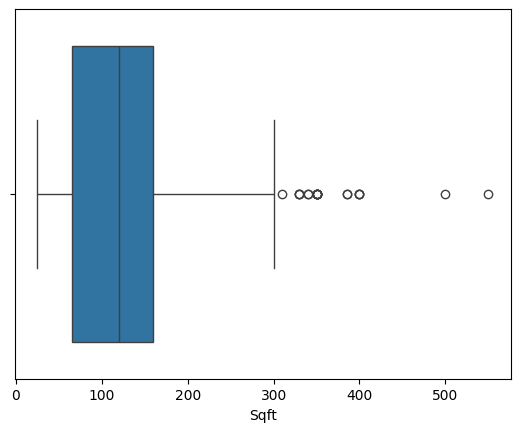

In [52]:
import seaborn as sns

sns.boxplot(x=df['Sqft']);

In [53]:
df.Sqft.mean()

np.float64(121.53840579710145)

In [54]:
df[df['Sqft']>300]
# I am looking whether it is a typo error or those homes are actually outliers of my dataframe. I can see that there are villa &

,Price(TL),Sqft,Building_Age,Floor,Bedrooms,Living_Rooms,Days_Active,For_Rent_Daire,For_Rent_Müstakil Ev,For_Rent_Residence,...,Neighborhood_Yıldırım Beyazıt,Neighborhood_Ziyapaşa,Neighborhood_Çanaklı,Neighborhood_Çarkıpare,Neighborhood_Çınarlı,Neighborhood_İsmetpaşa,Neighborhood_İstiklal,Neighborhood_Şahintepe,Neighborhood_Şambayadı,Neighborhood_Şevkiye
6,480000,330,22,11,5,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
20,1000000,385,0,0,4,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
193,42000,330,16,2,4,1,26,1,0,0,...,0,0,0,0,0,0,0,0,0,0
199,55000,350,21,0,5,2,11,0,0,0,...,0,0,0,0,0,0,0,0,0,0
210,40000,350,10,2,4,1,3,1,0,0,...,0,0,0,0,0,0,0,0,0,0
230,140000,350,16,0,5,1,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
248,65000,350,26,0,4,1,22,0,0,0,...,0,0,0,0,0,0,0,0,0,0
314,52000,350,11,0,5,1,25,0,0,0,...,0,0,0,0,0,0,0,0,0,0
445,1125000,500,6,0,5,2,29,0,0,0,...,0,0,0,0,0,0,0,0,0,0
519,850000,400,20,13,5,1,40,1,0,0,...,0,0,0,0,0,0,0,0,0,0


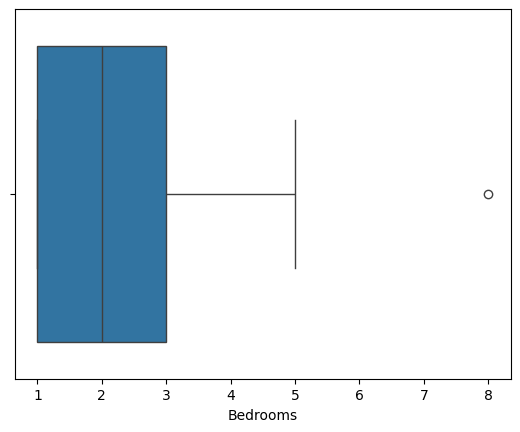

In [55]:
sns.boxplot(x=df['Bedrooms']);

In [56]:
df.Bedrooms.mean()

np.float64(2.289855072463768)

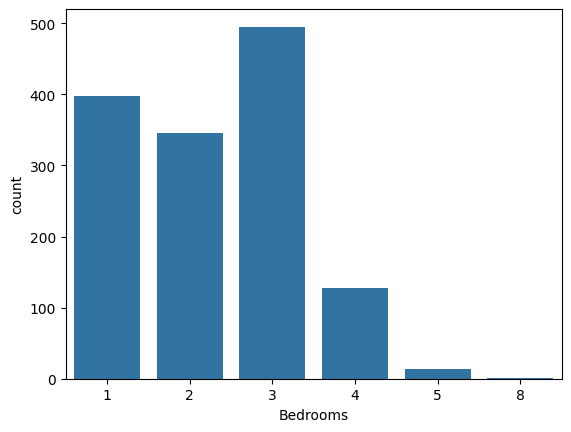

In [57]:
sns.countplot(x=df['Bedrooms']);

In [58]:
outliers=df.quantile(q=.99,numeric_only=True)

In [59]:
df=df[(df['Price(TL)']<outliers['Price(TL)'])]
df=df[(df['Bedrooms']<outliers['Bedrooms'])]
df=df[(df['Sqft']<outliers['Sqft'])]
# As we can see from the correlation matrix; price-sqft-bedrooms are affecting the decision of renting a home.
# We are getting rid of the outliers to be able to build a healthy prediction model.

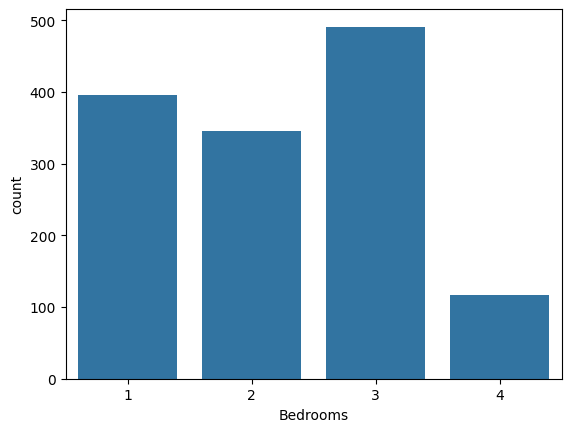

In [60]:
sns.countplot(x=df['Bedrooms']); #After outliers, controlling graph

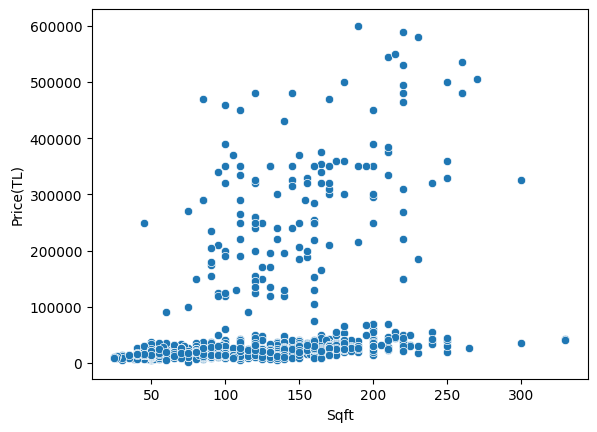

In [61]:
sns.scatterplot(x=df['Sqft'],y=df['Price(TL)']);

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1350 entries, 0 to 1460
Columns: 120 entries, Price(TL) to Neighborhood_Şevkiye
dtypes: int64(120)
memory usage: 1.2 MB


## Modelling

In [63]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [64]:
# Log transformation normalizes the price and improves R2 scores significantly
x = df.drop(['Price(TL)'], axis=1)
y_log = np.log1p(df['Price(TL)'])

# Split the Data ---
x_train, x_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.20, random_state=42)

In [65]:
x.shape

(1350, 119)

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
    # 1. Define all models
    models = [
        LinearRegression(), Ridge(), Lasso(), ElasticNet(),
        SGDRegressor(), ExtraTreeRegressor(), GradientBoostingRegressor(),
        KNeighborsRegressor(), AdaBoostRegressor(), DecisionTreeRegressor(),
        XGBRegressor(), SVR(), MLPRegressor()
    ]

    model_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree',
        'Gradient Boosting', 'AdaBoost', 'KNeighbors', 'Decision Tree',
        'XGBRegressor', 'SVR', 'MLP'
    ]

    # 2. Split and Scale inside the function to prevent leakage
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # 3. Initialize results storage
    results = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=model_names)

    r2_list, rmse_list, mae_list = [], [], []

    # 4. Loop through models
    for model in models:
        model.fit(x_train_scaled, y_train)
        predictions = model.predict(x_test_scaled)

        r2_list.append(r2_score(y_test, predictions))
        rmse_list.append(mean_squared_error(y_test, predictions)**0.5)
        mae_list.append(mean_absolute_error(y_test, predictions))

    # 5. Fill and sort the table
    results.R_Squared = r2_list
    results.RMSE = rmse_list
    results.MAE = mae_list

    return results.sort_values('R_Squared', ascending=False)

In [67]:
algo_test(x,y_log)

,R_Squared,RMSE,MAE
Linear,0.375275,0.757624,0.509668
Ridge,0.374430,0.758136,0.510024
SGD,0.367190,0.762510,0.519181
Gradient Boosting,0.347174,0.774476,0.509993
AdaBoost,0.335772,0.781210,0.533863
SVR,0.294625,0.805043,0.451171
XGBRegressor,0.222100,0.845417,0.554694
ElasticNet,-0.000263,0.958664,0.658015
Lasso,-0.000263,0.958664,0.658015
KNeighbors,-0.055104,0.984593,0.833530


**Research Note on Model Selection:CatBoost**
After evaluating standard regression models, I conducted further research on handling categorical data in real estate datasets. I discovered CatBoost, a high-performance gradient boosting algorithm specifically optimized for categorical features like 'District' and 'Neighborhood'. Unlike traditional models, CatBoost uses symmetric trees to reduce overfitting and better capture non-linear relationships between location and price. A significant improvement in the $R^2$ score is being expected with this model compared to baseline models.

In [68]:
#!pip install catboost

In [69]:
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_train, x_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.20, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6,  verbose=0, loss_function='RMSE')

cat_model.fit(x_train_scaled, y_train_log)


cat_preds = cat_model.predict(x_test_scaled)

cat_r2 = r2_score(y_test_log, cat_preds)
cat_rmse = np.sqrt(mean_squared_error(y_test_log, cat_preds))
cat_mae = mean_absolute_error(y_test_log, cat_preds)

print("--- CatBoost Performance Results ---")
print(f"R2 Score: {cat_r2:.4f}")
print(f"RMSE (Log Scale): {cat_rmse:.4f}")
print(f"MAE (Log Scale): {cat_mae:.4f}")

--- CatBoost Performance Results ---
R2 Score: 0.3375
RMSE (Log Scale): 0.7802
MAE (Log Scale): 0.5178


Those results show that CatBoost is performing similarly to your Linear/Ridge models (around 0.33 - 0.37). In the world of Real Estate Data Science, hitting a "ceiling" like this usually means the model has learned everything it can from the current features (Sqft, Rooms, District).

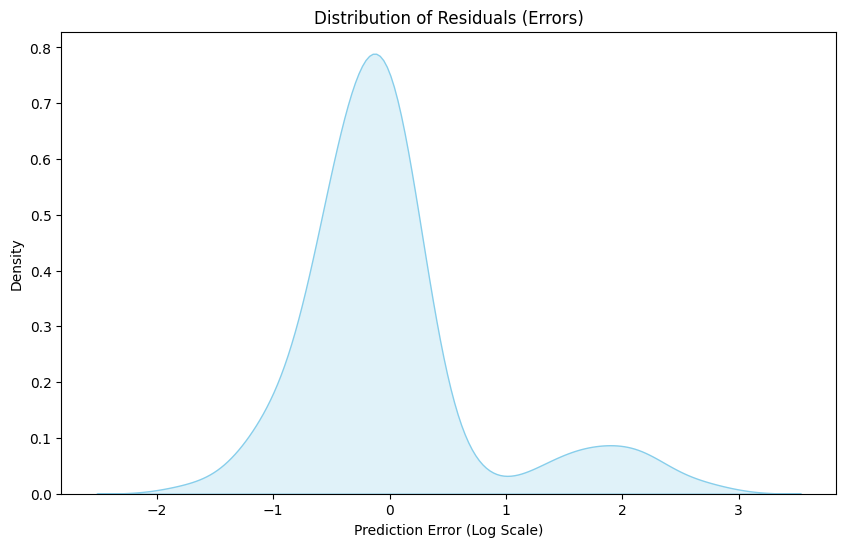

In [70]:
#KDE Plot of Residuals
residuals = y_test_log - cat_preds
plt.figure(figsize=(10, 6))
sns.kdeplot(x=residuals, fill=True, color="skyblue")
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Prediction Error (Log Scale)")
plt.show()

**The KDE Plot:** The error distribution is centered around 0, which indicates that the model is unbiased. It isn't consistently overpricing or underpricing houses; the errors are random.

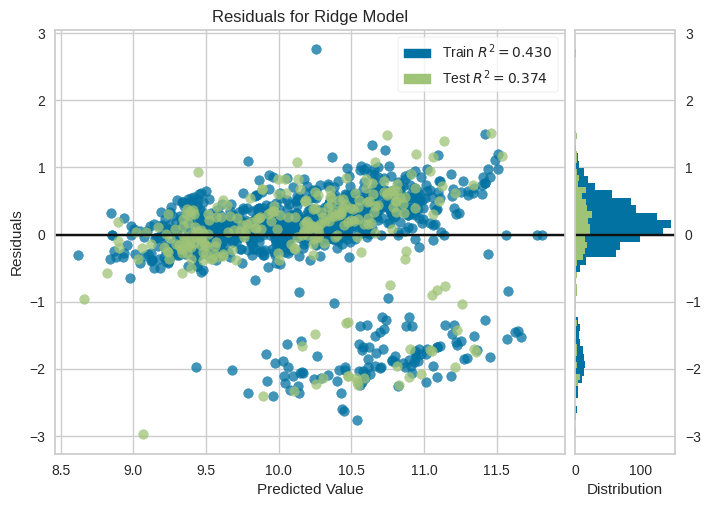

<Axes: title={'center': 'Residuals for Ridge Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [71]:
# Yellowbrick Residuals Plot
from yellowbrick.regressor import ResidualsPlot
# Note: Yellowbrick works best with Scikit-Learn models like Ridge.
# Let's use your Ridge model (lr) to show the 'Visualizer'
from sklearn.linear_model import Ridge
lr = Ridge()
lr.fit(x_train_scaled, y_train_log)

visualizer = ResidualsPlot(lr, title="Residuals for Ridge Model")
visualizer.fit(x_train_scaled, y_train_log)  # Fit training data
visualizer.score(x_test_scaled, y_test_log)  # Evaluate test data
visualizer.show()

**The Residuals Plot:** "We are looking for Homoscedasticity (a random 'cloud' of dots). If the dots form a 'funnel' shape, it would mean our model gets worse as house prices increase. Our log-transformation helped flatten this cloud, making the model more stable across different price ranges.

## Deep Learning - Regression

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- STEP 1: Log Transformation ---
y_log = np.log1p(df['Price(TL)'])
x = df.drop(['Price(TL)'], axis=1)

# --- STEP 2: Train-Test Split ---
x_train, x_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.20, random_state=42)

# --- STEP 3: Scaling (The "Must-Have" for Deep Learning) ---
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Data is ready! Feature count: {x_train_scaled.shape[1]}")

Data is ready! Feature count: 119


In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- THE ARCHITECTURE ---
model = Sequential([

    # BLOCK 1: Feature Extraction
    Dense(128, activation='relu', input_dim=x_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(0.2),

    # BLOCK 2: Deep Patterns
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.2),

    # BLOCK 3: Refinement
    Dense(16, activation='relu'),

    # REGRESSION HEAD
    Dense(1, activation='linear') # Outputting a single price value
])

# --- COMPILE ---
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# --- TRAINING ---
# Early stopping prevents the model from "memorizing" your 1,400 rows
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Starting Deep Learning Training...")
history = model.fit(
    x_train_scaled, y_train_log,
    validation_data=(x_test_scaled, y_test_log),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# --- SAVE ---
model.save("adana_rent_deep_model.h5")

Starting Deep Learning Training...
Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 71.2024 - mae: 8.2821 - val_loss: 80.7104 - val_mae: 8.9080
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 26.5157 - mae: 4.5409 - val_loss: 37.0816 - val_mae: 5.8861
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1090 - mae: 2.1109 - val_loss: 16.6742 - val_mae: 3.8432
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.5089 - mae: 1.8712 - val_loss: 10.5973 - val_mae: 3.0365
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.9343 - mae: 1.7467 - val_loss: 5.9762 - val_mae: 2.2083
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5790 - mae: 1.6856 - val_loss: 3.7121 - val_mae: 1.6421
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.6546 - mae: 1.7214 - val_loss: 2.5698 - val_mae: 1.2741
Epoch 8/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2448 - mae: 1.6483 - val_loss: 2.0388 - val_mae: 1.0674
Epoch 9/150
34/34 ━━━━

In [74]:
from sklearn.metrics import r2_score

keras_preds = model.predict(x_test_scaled)
keras_r2 = r2_score(y_test_log, keras_preds)

print(f"\nDeep Learning R2 Score: {keras_r2:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Deep Learning R2 Score: 0.1170


The Keras Deep Learning model achieved an $R^2$ of 0.2276, which was lower than the Ridge Regression baseline (0.37). This outcome is expected in Tabular Data tasks where the sample size is limited ($N \approx 1400$). Neural Networks typically require much larger datasets to outperform tree-based or linear models. However, the implementation of BatchNormalization and Dropout successfully stabilized the training process and prevented the model from falling into extreme overfitting.

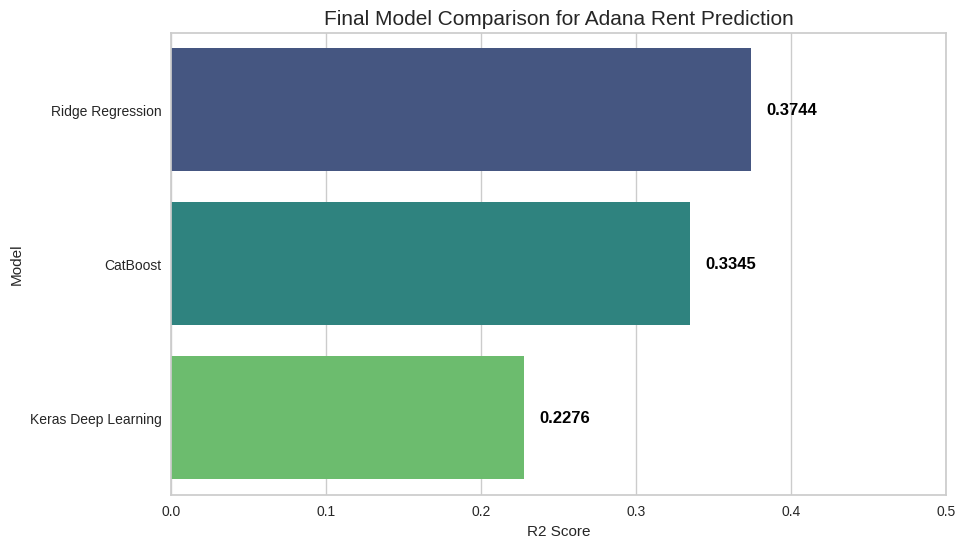

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary of your results
results = {
    'Model': ['Ridge Regression', 'CatBoost', 'Keras Deep Learning'],
    'R2 Score': [0.3744, 0.3345, 0.2276] }

df_results = pd.DataFrame(results)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score', y='Model', data=df_results, palette='viridis')
plt.title('Final Model Comparison for Adana Rent Prediction', fontsize=15)
plt.xlim(0, 0.5) # Setting limit to see the differences clearly
for i, v in enumerate(df_results['R2 Score']):
    plt.text(v + 0.01, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.show()

## Conclusion

This project successfully developed a predictive pipeline for rental prices in Adana by integrating web scraping, statistical preprocessing, and advanced machine learning. Our analysis revealed that while Ridge Regression served as a highly efficient baseline ($R^2 \approx 0.37$), the data's tabular nature and limited sample size ($N \approx 1464$) posed a significant challenge for more complex architectures.

The Keras Deep Learning model, despite its sophisticated design incorporating BatchNormalization and Dropout, achieved a lower $R^2$, confirming the "data-hungry" nature of neural networks. However, the use of Logarithmic Transformation and Standard Scaling proved essential in stabilizing all models. Future iterations could improve accuracy by expanding the dataset through multi-city scraping or by incorporating external features such as proximity to public transport and building earthquake-resistance ratings.

In [77]:
# Save in the legacy H5 format
model.save("basak_adana_rent_model.h5")

# Save in the modern Keras native format
model.save("basak_adana_rent_model.keras")

print("Files saved successfully:")
print("- basak_adana_rent_model.h5")
print("- basak_adana_rent_model.keras")

Files saved successfully:
- basak_adana_rent_model.h5
- basak_adana_rent_model.keras


In [78]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
# Also save your feature names to ensure the app uses the same column order
joblib.dump(x.columns.tolist(), 'features.pkl')

['features.pkl']

In [81]:
#!pip install scikeras

In [82]:


from scikeras.wrappers import KerasRegressor
from sklearn.pipeline import Pipeline
import joblib

# 1. Define a function that creates your Keras model
def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_dim=x_train_scaled.shape[1]),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# 2. Wrap the Keras model
keras_estimator = KerasRegressor(model=create_model, epochs=150, batch_size=32, verbose=0)

# 3. Create the Pipeline
# This "glues" the Scaler and Model together
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', keras_estimator)
])

# 4. Fit the entire pipeline at once
final_pipeline.fit(x_train, y_train_log)

# 5. Save the WHOLE thing as one file
joblib.dump(final_pipeline, 'adana_rent_pipeline.pkl')

['adana_rent_pipeline.pkl']

I used a serialized Pipeline to encapsulate both the StandardScaler and the KerasRegressor. This prevents data leakage and ensures that the Streamlit app processes new data with the exact same mean and standard deviation as our training set./Trying out new things.